In [1]:
#Dependencies
# Uncomment if needed
!pip install datasets

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from datasets import load_dataset
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

#device check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


In [3]:
#Loading the dataset
print('Downloading dataset (first time may take a few minutes)...')
raw_dataset = load_dataset('microsoft/cats_vs_dogs', split='train')
print(f'Dataset loaded: {len(raw_dataset)} images')

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/330M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/391M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/23410 [00:00<?, ? examples/s]

Dataset loaded: 23410 images


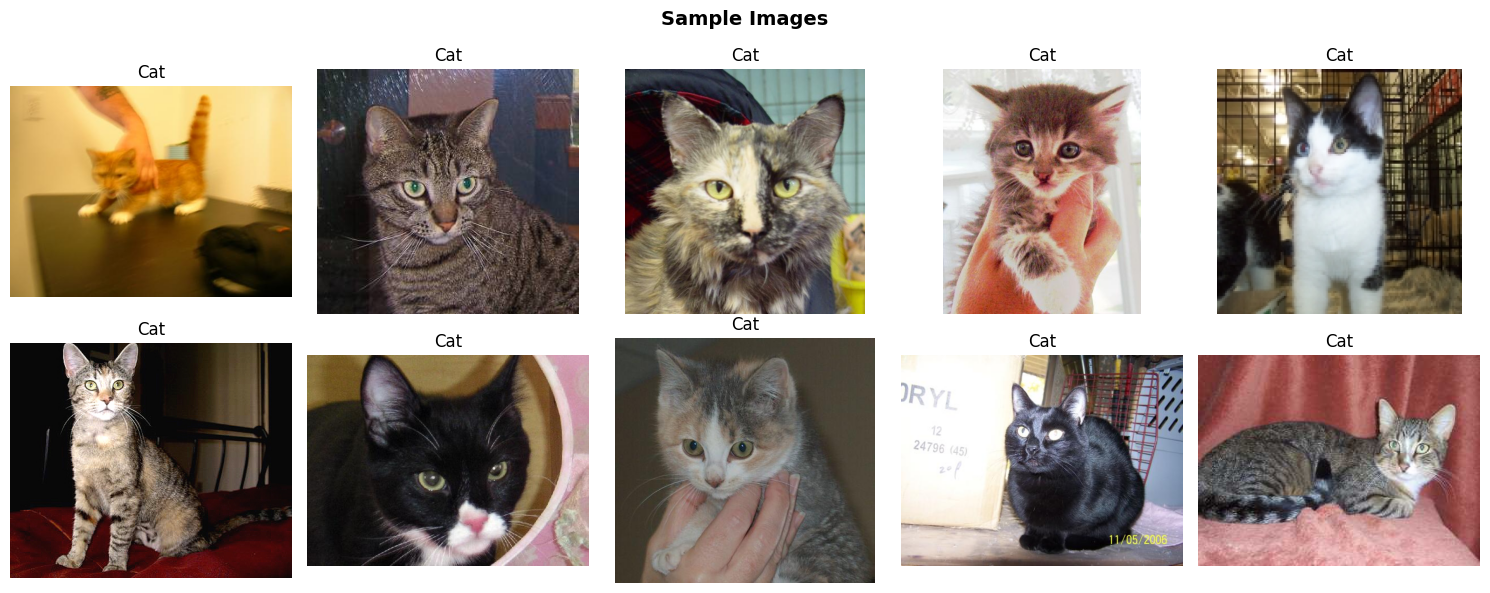

In [4]:
#Samples Preview
CLASS_NAMES = ['Cat', 'Dog']

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    sample = raw_dataset[i]
    ax.imshow(sample['image'])
    ax.set_title(CLASS_NAMES[sample['labels']])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [5]:
#Trabsforms and Data Set Class
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class CatsDogsDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.data = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        image = sample['image'].convert('RGB')
        label = sample['labels']
        if self.transform:
            image = self.transform(image)
        return image, label

In [6]:
#Training and Validation Split. Also Dataloaders
n_total = len(raw_dataset)
n_train = int(0.8 * n_total)

indices = list(range(n_total))
np.random.seed(42)
np.random.shuffle(indices)

train_hf = raw_dataset.select(indices[:n_train])
val_hf   = raw_dataset.select(indices[n_train:])

train_dataset = CatsDogsDataset(train_hf, transform=train_transforms)
val_dataset   = CatsDogsDataset(val_hf,   transform=val_transforms)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_dataset):,}  |  Val: {len(val_dataset):,}')

Train: 18,728  |  Val: 4,682


In [7]:
#Model Building

def build_model(freeze_backbone=True):
    model = models.resnet50(weights='IMAGENET1K_V2')
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, 2),
    )
    return model

model = build_model(freeze_backbone=True).to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 138MB/s]


Trainable params: 525,058 / 24,033,090


In [8]:
#Training Set Up

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-4
)
NUM_EPOCHS = 5
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [9]:
#Training and Evaluation Functions
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc='  Train', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc='  Val  ', leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

In [10]:
#Running the Training loop
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\nEpoch {epoch}/{NUM_EPOCHS}')
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'  Train — loss: {train_loss:.4f}  acc: {train_acc*100:.2f}%')
    print(f'  Val   — loss: {val_loss:.4f}  acc: {val_acc*100:.2f}%')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_cat_dog_model.pth')
        print('  ✅ Best model saved.')

print(f'\nDone! Best val accuracy: {best_val_acc*100:.2f}%')


Epoch 1/5


  Train — loss: 0.0739  acc: 97.26%
  Val   — loss: 0.0276  acc: 99.00%
  ✅ Best model saved.

Epoch 2/5


  Train — loss: 0.0510  acc: 98.17%
  Val   — loss: 0.0235  acc: 99.06%
  ✅ Best model saved.

Epoch 3/5


  Train — loss: 0.0454  acc: 98.31%
  Val   — loss: 0.0264  acc: 99.00%

Epoch 4/5


  Train — loss: 0.0371  acc: 98.53%
  Val   — loss: 0.0220  acc: 99.04%

Epoch 5/5


  Train — loss: 0.0330  acc: 98.85%
  Val   — loss: 0.0229  acc: 99.04%

Done! Best val accuracy: 99.06%


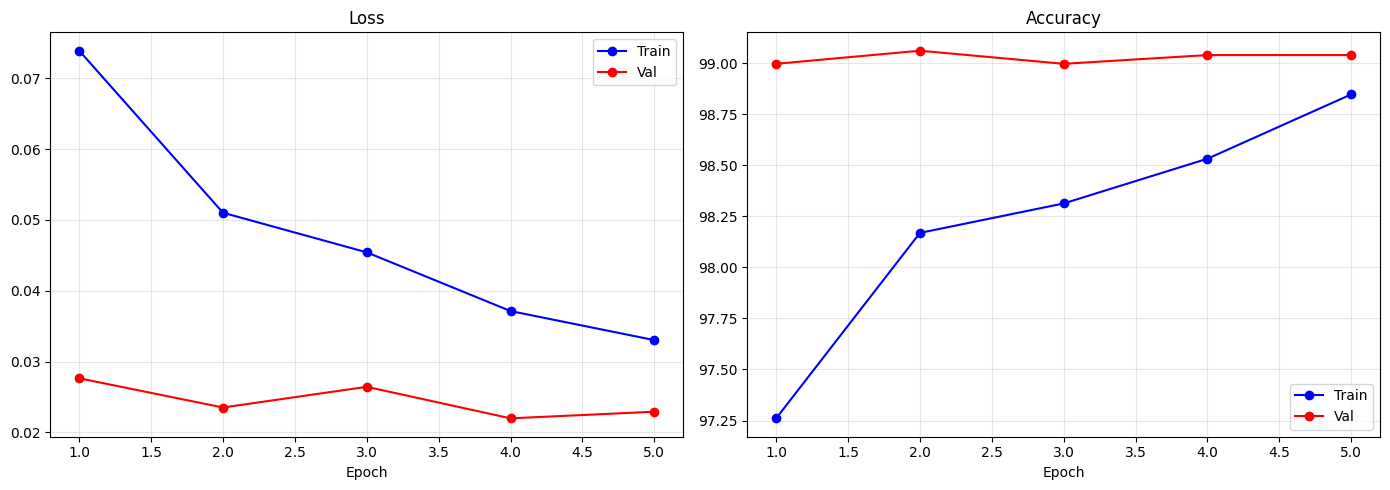

In [11]:
#Plotting The Training Curves

epochs_range = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train')
ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', label='Train')
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],   'r-o', label='Val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

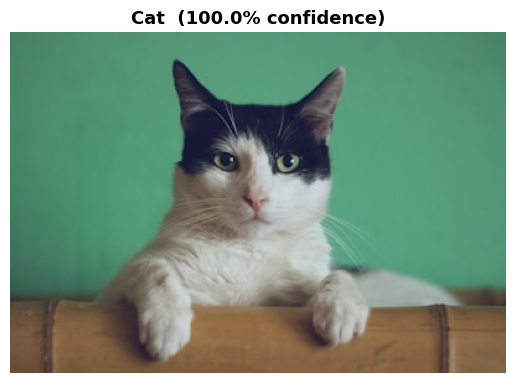

In [15]:
import requests
from io import BytesIO

def predict_from_url(url):
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url, headers=headers)
    image = Image.open(BytesIO(response.content)).convert('RGB')

    model.load_state_dict(torch.load('best_cat_dog_model.pth', map_location=device))
    model.eval()
    tensor = val_transforms(image).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).squeeze().cpu().numpy()

    pred, conf = CLASS_NAMES[probs.argmax()], probs.max() * 100
    plt.imshow(image)
    plt.title(f'{pred}  ({conf:.1f}% confidence)', fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.show()

# Test it:
predict_from_url('https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=400')